In [58]:
# DATA HANDLING
import pandas as pd
import numpy as np

# VISUALIZATION (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# SKLEARN - MODEL BUILDING
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# METRICS
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# MODELS
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor

# EXPLAINABILITY
import shap

# MODEL SAVING
import joblib

In [59]:
df = pd.read_csv("/content/Loan prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [60]:
df = df.drop(columns=["Loan_ID"])
df["Loan_Status"] = df["Loan_Status"].map({"Y": 0, "N": 1})
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [61]:
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["Loan_Income_Ratio"] = df["LoanAmount"] / (df["Total_Income"] + 1)

In [62]:
X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]

In [63]:
X = pd.get_dummies(X, drop_first=True)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=2,
        random_state=42
    ))
])

In [66]:
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 5, 6],
    "model__learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [67]:
df["EMI_Income_Ratio"] = df["LoanAmount"] / (df["Total_Income"] + 1)
df["Income_Log"] = np.log1p(df["Total_Income"])

In [68]:
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [69]:
param_grid = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

In [71]:
from sklearn.base import clone

# Clone the pipeline to avoid modifying the original if it's used elsewhere
cloned_pipeline = clone(pipeline)

cloned_pipeline.named_steps['model'].objective = 'binary:logistic'

grid = GridSearchCV(
    cloned_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=200,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.7, 0.8, 1.0],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 4, 5, 6],
                         'model__n_estimators': [200, 300, 400],
                         'model__subsample': [0.7, 0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [72]:
best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'model__colsample_bytree': 0.7, 'model__learning_rate': 0.01, 'model__max_depth': 6, 'model__n_estimators': 400, 'model__subsample': 1.0}


In [73]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7476744186046511
              precision    recall  f1-score   support

           0       0.77      0.90      0.83        80
           1       0.73      0.51      0.60        43

    accuracy                           0.76       123
   macro avg       0.75      0.71      0.72       123
weighted avg       0.76      0.76      0.75       123



In [74]:
thresholds = np.arange(0.2, 0.6, 0.05)
for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    acc = (y_pred_t == y_test).mean()
    print(f"Threshold: {t:.2f} | Accuracy: {acc:.4f}")

Threshold: 0.20 | Accuracy: 0.5528
Threshold: 0.25 | Accuracy: 0.6098
Threshold: 0.30 | Accuracy: 0.6585
Threshold: 0.35 | Accuracy: 0.7642
Threshold: 0.40 | Accuracy: 0.7724
Threshold: 0.45 | Accuracy: 0.7886
Threshold: 0.50 | Accuracy: 0.7642
Threshold: 0.55 | Accuracy: 0.7724


In [75]:
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

best_model.named_steps["model"].set_params(scale_pos_weight=scale)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [78]:
model = best_model.named_steps["model"]
X_test_processed = best_model.named_steps["imputer"].transform(X_test)

In [79]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test_processed)

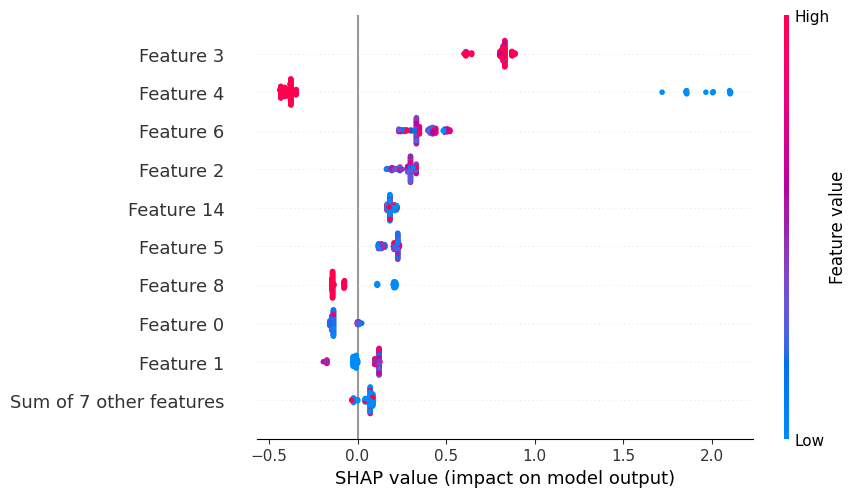

In [80]:
shap.plots.beeswarm(shap_values)

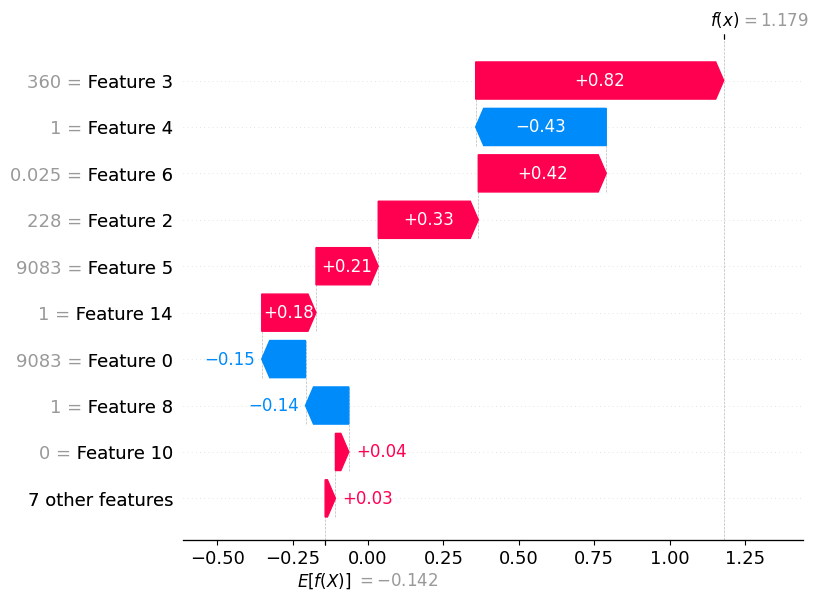

In [81]:
shap.plots.waterfall(shap_values[0])

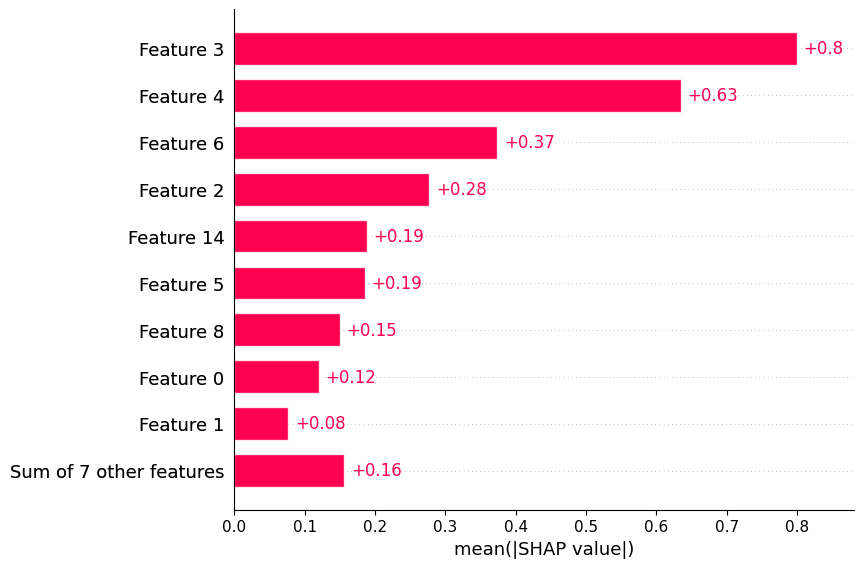

In [82]:
shap.plots.bar(shap_values)

In [83]:
feature_names = X.columns
shap_values.feature_names = feature_names

In [84]:
def explain_prediction(index):
    shap.plots.waterfall(shap_values[index])

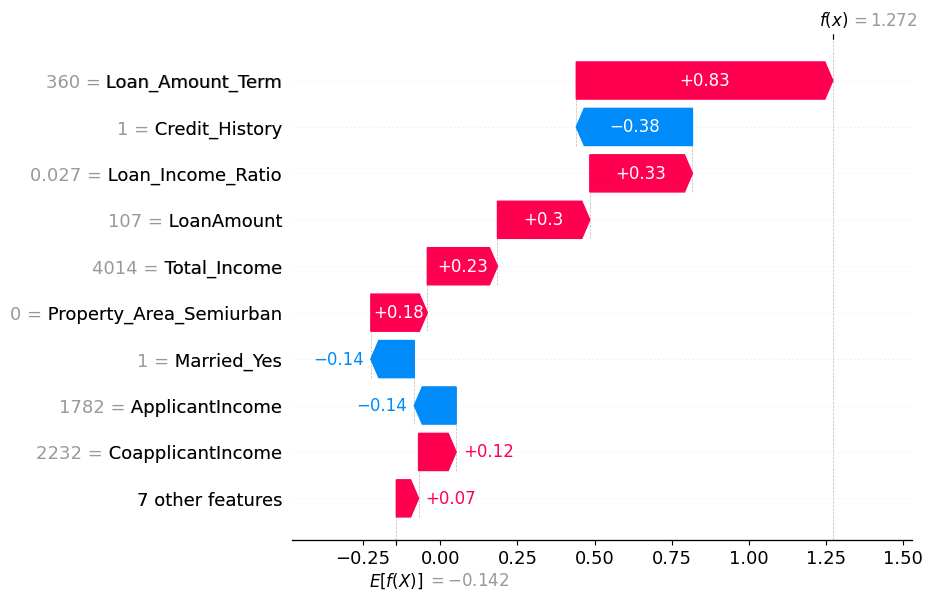

In [85]:
explain_prediction(5)

In [86]:
y_prob_all = best_model.predict_proba(X)[:, 1]
credit_limit_target = df["LoanAmount"] * (1 - y_prob_all)

In [87]:
X_reg = X.copy()
y_reg = df["LoanAmount"]

In [91]:
reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    ))
])
y_train_reg = y_reg.loc[X_train.index]

valid_indices = y_train_reg.dropna().index
X_train_cleaned = X_train.loc[valid_indices]
y_train_reg_cleaned = y_train_reg.loc[valid_indices]

reg_pipeline.fit(X_train_cleaned, y_train_reg_cleaned)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [92]:
credit_pred = reg_pipeline.predict(X_test)

In [93]:
final_output = []

for i in range(len(X_test)):
    risk = y_prob[i]
    limit = credit_pred[i]

    if risk > 0.4:
        decision = "Reject"
        limit = 0
    else:
        decision = "Approve"
        limit = limit * (1 - risk)  # adjust by risk

    final_output.append((decision, risk, limit))

In [97]:
from sklearn.metrics import mean_absolute_error

y_test_reg = y_reg.loc[X_test.index]

temp_df = pd.DataFrame({'y_true': y_test_reg, 'y_pred': credit_pred}, index=X_test.index)

temp_df_cleaned = temp_df.dropna(subset=['y_true'])

print("MAE:", mean_absolute_error(temp_df_cleaned['y_true'], temp_df_cleaned['y_pred']))

MAE: 0.930064454037919


TESTING

In [111]:
sample = X_test.iloc[3:13]
sample

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Loan_Income_Ratio,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
609,2900,0.0,71.0,360.0,1.0,2900.0,0.024474,False,False,False,False,False,False,False,False,False
132,2718,0.0,70.0,360.0,1.0,2718.0,0.025745,True,False,False,False,False,False,False,True,False
578,1782,2232.0,107.0,360.0,1.0,4014.0,0.026650,True,True,True,False,False,False,False,False,False
316,3717,0.0,120.0,360.0,1.0,3717.0,0.032275,True,True,False,True,False,False,False,True,False
2,3000,0.0,66.0,360.0,1.0,3000.0,0.021993,True,True,False,False,False,False,True,False,True
340,2647,1587.0,173.0,360.0,1.0,4234.0,0.040850,True,True,False,False,True,True,False,False,False
77,1000,3022.0,110.0,360.0,1.0,4022.0,0.027343,True,True,True,False,False,False,True,False,True
218,5000,0.0,72.0,360.0,0.0,5000.0,0.014397,True,True,False,True,False,False,False,True,False
462,3015,2188.0,153.0,360.0,1.0,5203.0,0.029400,True,True,False,False,False,False,False,False,False
109,2071,754.0,94.0,480.0,1.0,2825.0,0.033263,True,True,False,False,True,True,False,True,False


In [112]:
#Risk
X_test_processed = best_model.named_steps["imputer"].transform(sample)
risk_probs = best_model.named_steps["model"].predict_proba(X_test_processed)[:, 1]

#Credit limit
X_reg_processed = reg_pipeline.named_steps["imputer"].transform(sample)
credit_limits = reg_pipeline.named_steps["model"].predict(X_reg_processed)

In [113]:
threshold = 0.4

results = []

for i in range(len(sample)):
    risk = risk_probs[i]
    limit = credit_limits[i]

    if risk > threshold:
        decision = "Rejected"
        final_limit = 0
    else:
        decision = "Approved"
        final_limit = limit * (1 - risk)

    results.append((risk, decision, final_limit))

In [114]:
output_df = sample.copy()
output_df["Risk_Probability"] = risk_probs
output_df["Decision"] = [r[1] for r in results]
output_df["Recommended_Limit"] = [r[2] for r in results]
output_df

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Loan_Income_Ratio,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Risk_Probability,Decision,Recommended_Limit
609,2900,0.0,71.0,360.0,1.0,2900.0,0.024474,False,False,False,False,False,False,False,False,False,0.801054,Rejected,0
132,2718,0.0,70.0,360.0,1.0,2718.0,0.025745,True,False,False,False,False,False,False,True,False,0.822880,Rejected,0
578,1782,2232.0,107.0,360.0,1.0,4014.0,0.026650,True,True,True,False,False,False,False,False,False,0.781058,Rejected,0
316,3717,0.0,120.0,360.0,1.0,3717.0,0.032275,True,True,False,True,False,False,False,True,False,0.764789,Rejected,0
2,3000,0.0,66.0,360.0,1.0,3000.0,0.021993,True,True,False,False,False,False,True,False,True,0.764789,Rejected,0
340,2647,1587.0,173.0,360.0,1.0,4234.0,0.040850,True,True,False,False,True,True,False,False,False,0.781058,Rejected,0
77,1000,3022.0,110.0,360.0,1.0,4022.0,0.027343,True,True,True,False,False,False,True,False,True,0.781058,Rejected,0
218,5000,0.0,72.0,360.0,0.0,5000.0,0.014397,True,True,False,True,False,False,False,True,False,0.965704,Rejected,0
462,3015,2188.0,153.0,360.0,1.0,5203.0,0.029400,True,True,False,False,False,False,False,False,False,0.781058,Rejected,0
109,2071,754.0,94.0,480.0,1.0,2825.0,0.033263,True,True,False,False,True,True,False,True,False,0.781058,Rejected,0


In [115]:
output_df["Actual"] = y_test.iloc[3:13].values
output_df

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Loan_Income_Ratio,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Risk_Probability,Decision,Recommended_Limit,Actual
609,2900,0.0,71.0,360.0,1.0,2900.0,0.024474,False,False,False,False,False,False,False,False,False,0.801054,Rejected,0,0
132,2718,0.0,70.0,360.0,1.0,2718.0,0.025745,True,False,False,False,False,False,False,True,False,0.822880,Rejected,0,0
578,1782,2232.0,107.0,360.0,1.0,4014.0,0.026650,True,True,True,False,False,False,False,False,False,0.781058,Rejected,0,0
316,3717,0.0,120.0,360.0,1.0,3717.0,0.032275,True,True,False,True,False,False,False,True,False,0.764789,Rejected,0,0
2,3000,0.0,66.0,360.0,1.0,3000.0,0.021993,True,True,False,False,False,False,True,False,True,0.764789,Rejected,0,0
340,2647,1587.0,173.0,360.0,1.0,4234.0,0.040850,True,True,False,False,True,True,False,False,False,0.781058,Rejected,0,1
77,1000,3022.0,110.0,360.0,1.0,4022.0,0.027343,True,True,True,False,False,False,True,False,True,0.781058,Rejected,0,1
218,5000,0.0,72.0,360.0,0.0,5000.0,0.014397,True,True,False,True,False,False,False,True,False,0.965704,Rejected,0,1
462,3015,2188.0,153.0,360.0,1.0,5203.0,0.029400,True,True,False,False,False,False,False,False,False,0.781058,Rejected,0,0
109,2071,754.0,94.0,480.0,1.0,2825.0,0.033263,True,True,False,False,True,True,False,True,False,0.781058,Rejected,0,0


In [117]:
# High risk cases
high_risk_samples = X_test[y_test == 1].head(5)
# Low risk cases
low_risk_samples = X_test[y_test == 0].head(5)

Explanation for a High-Risk Case:


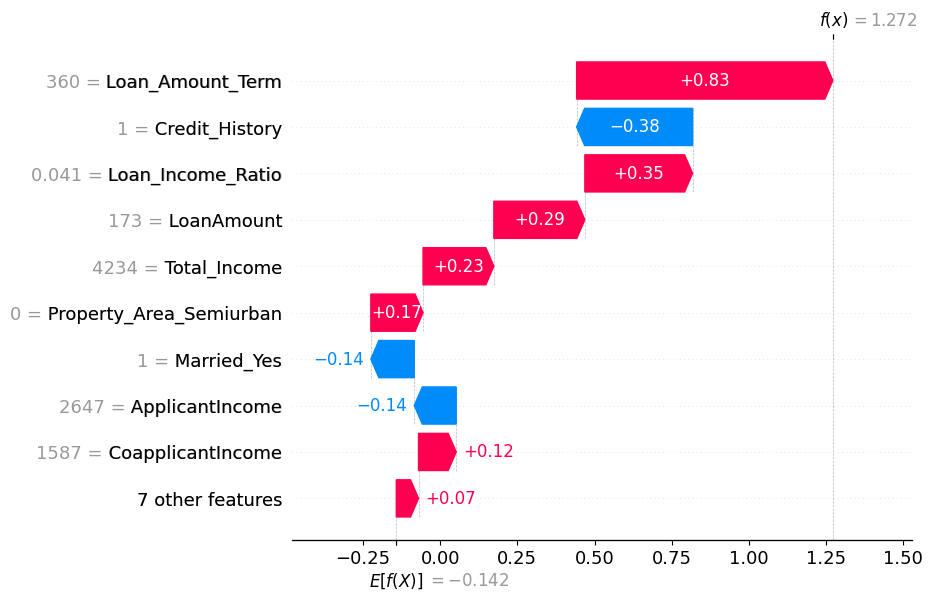


Explanation for a Low-Risk Case:


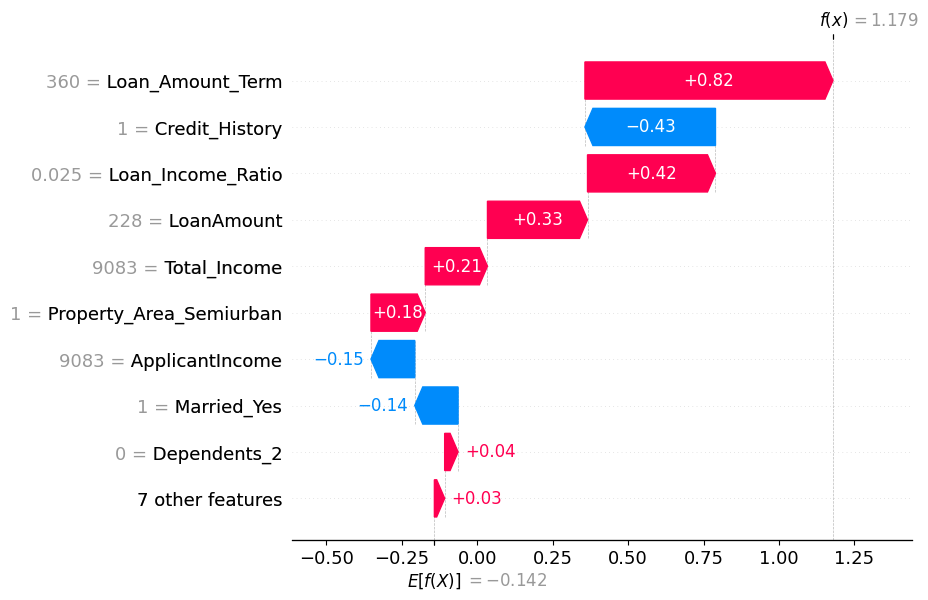

In [119]:
high_risk_processed = best_model.named_steps["imputer"].transform(high_risk_samples.iloc[[0]])
shap_values_high_risk = explainer(high_risk_processed)
shap_values_high_risk.feature_names = X.columns
print("Explanation for a High-Risk Case:")
shap.plots.waterfall(shap_values_high_risk[0])
low_risk_processed = best_model.named_steps["imputer"].transform(low_risk_samples.iloc[[0]])
shap_values_low_risk = explainer(low_risk_processed)
shap_values_low_risk.feature_names = X.columns
print("\nExplanation for a Low-Risk Case:")
shap.plots.waterfall(shap_values_low_risk[0])